In [430]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as svp



# --- Runtime configuration ---
warnings.filterwarnings("ignore")

In [431]:
sim_end_year = 2050


In [432]:
def get_file_structure(
    y0: int = 2015,
    y1: int = sim_end_year,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    # setup some SISEPUEDE variables and update time period
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    # get some keys
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year
 
 
    ##  BUILD THE ATTRIBUTE AND UPDATE
 
    # setup the new attribute table
    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    # finally, update the ModelAttributes inside the file structure
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    # return the tuple
    out = (file_struct, attribute_time_period, )
 
    return out



# model attributes and associated support classes
_EXAMPLES = sxl.SISEPUEDEExamples()
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure(y1=sim_end_year)
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )
 

In [433]:
# setup models in case we need them
models = sm.SISEPUEDEModels(
    matt,
    allow_electricity_run = True,
    fp_julia = _FILE_STRUCTURE.dir_jl,
    fp_nemomod_reference_files = _FILE_STRUCTURE.dir_ref_nemo,
    initialize_julia = True, 
)

In [434]:
df = pd.read_csv("ssp_libya_inputs_02032026.csv")
df.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,region
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0,0.0,1.0,1.0,1.0,1.0,1.0,LBY,libya


## Population


Text(0.5, 0, 'Year')

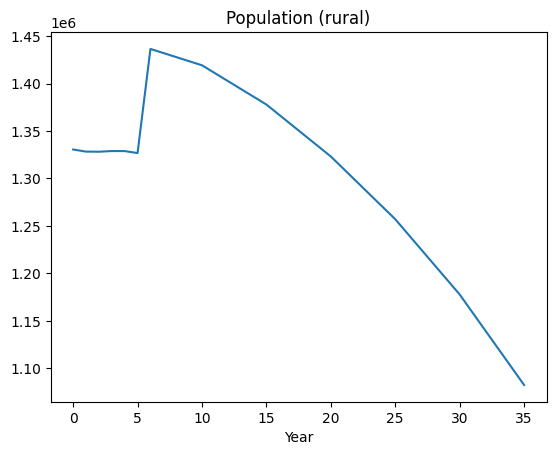

In [435]:
df['population_gnrl_rural'].plot()
plt.title('Population (rural)')
plt.xlabel('Year')

Text(0.5, 0, 'Year')

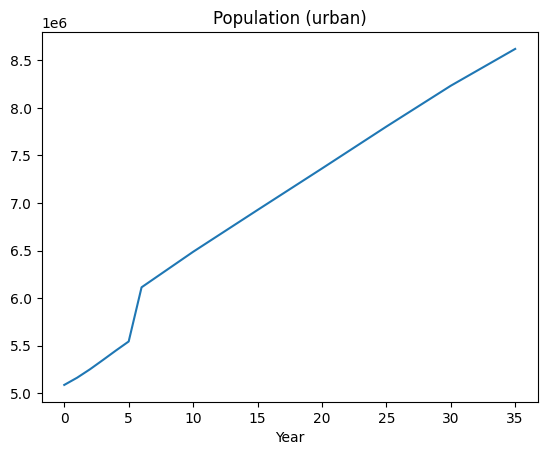

In [436]:
df['population_gnrl_urban'].plot()
plt.title('Population (urban)')
plt.xlabel('Year')

In [437]:
wb = pd.read_csv("temp/wbccdb_raw.csv")
wb.head()

,date,country.value,NY.GDP.MKTP.PP.CD,SP.POP.TOTL,SP.RUR.TOTL,SP.URB.TOTL
0,1981,Libya,NaN,3621486.0,1016169.0,2605317.0
1,1982,Libya,NaN,3724765.0,998070.0,2726695.0
2,1983,Libya,NaN,3718961.0,954518.0,2764443.0
3,1984,Libya,NaN,3773633.0,931227.0,2842406.0
4,1985,Libya,NaN,3898745.0,926620.0,2972125.0


In [438]:
# if needed, rerun the cell that loads wb first
wb = wb[wb["date"] >= 2015]
wb.head()

,date,country.value,NY.GDP.MKTP.PP.CD,SP.POP.TOTL,SP.RUR.TOTL,SP.URB.TOTL
34,2015,Libya,1.169408e+11,6531819.0,795843.0,5735976.0
35,2016,Libya,1.124876e+11,6632126.0,808058.0,5824068.0
36,2017,Libya,1.214732e+11,6738770.0,821006.0,5917764.0
37,2018,Libya,1.293055e+11,6849055.0,834319.0,6014736.0
38,2019,Libya,1.125658e+11,6951033.0,846496.0,6104537.0


In [439]:
import numpy as np

target_year = 2050  # change to 2150 if you really meant that

wb = wb.sort_values("date").copy()

# Numeric columns to project (excluding date)
num_cols = [c for c in wb.select_dtypes(include="number").columns if c != "date"]

# Build full year range
full_years = pd.DataFrame({"date": range(int(wb["date"].min()), target_year + 1)})
wb_proj = full_years.copy()

# Keep country label
country_val = wb["country.value"].dropna().iloc[0] if wb["country.value"].notna().any() else None
wb_proj["country.value"] = country_val

for col in num_cols:
    known = wb[["date", col]].dropna()

    if len(known) >= 2:
        m, b = np.polyfit(known["date"], known[col], 1)
        wb_proj[col] = m * wb_proj["date"] + b
    elif len(known) == 1:
        wb_proj[col] = known[col].iloc[0]
    else:
        wb_proj[col] = np.nan

    # Preserve original observed values
    wb_proj.loc[wb_proj["date"].isin(known["date"]), col] = (
        wb_proj.loc[wb_proj["date"].isin(known["date"]), "date"]
        .map(known.set_index("date")[col])
        .values
    )

# Optional: avoid negative projected values
wb_proj[num_cols] = wb_proj[num_cols].clip(lower=0)

wb = wb_proj
wb.tail()

,date,country.value,NY.GDP.MKTP.PP.CD,SP.POP.TOTL,SP.RUR.TOTL,SP.URB.TOTL
31,2046,Libya,2.547606e+10,9.506598e+06,1.142928e+06,8363669.8
32,2047,Libya,2.245440e+10,9.601964e+06,1.154021e+06,8447943.6
33,2048,Libya,1.943273e+10,9.697331e+06,1.165113e+06,8532217.4
34,2049,Libya,1.641106e+10,9.792697e+06,1.176206e+06,8616491.2
35,2050,Libya,1.338940e+10,9.888064e+06,1.187299e+06,8700765.0


<Axes: >

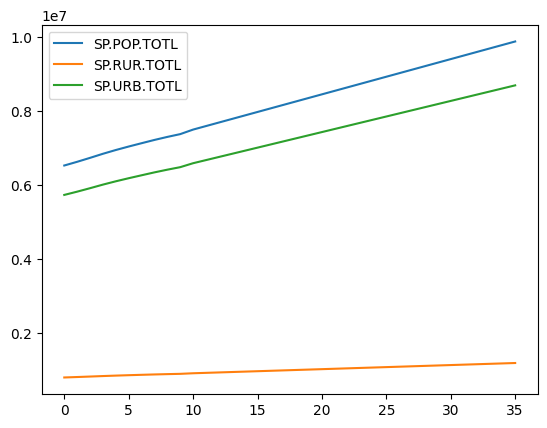

In [440]:
wb[['SP.POP.TOTL','SP.RUR.TOTL','SP.URB.TOTL']].plot()

In [441]:
wb['time_period'] = wb['date']-2015
wb.head()

,date,country.value,NY.GDP.MKTP.PP.CD,SP.POP.TOTL,SP.RUR.TOTL,SP.URB.TOTL,time_period
0,2015,Libya,1.169408e+11,6531819.0,795843.0,5735976.0,0
1,2016,Libya,1.124876e+11,6632126.0,808058.0,5824068.0,1
2,2017,Libya,1.214732e+11,6738770.0,821006.0,5917764.0,2
3,2018,Libya,1.293055e+11,6849055.0,834319.0,6014736.0,3
4,2019,Libya,1.125658e+11,6951033.0,846496.0,6104537.0,4


In [442]:
wb.tail()

,date,country.value,NY.GDP.MKTP.PP.CD,SP.POP.TOTL,SP.RUR.TOTL,SP.URB.TOTL,time_period
31,2046,Libya,2.547606e+10,9.506598e+06,1.142928e+06,8363669.8,31
32,2047,Libya,2.245440e+10,9.601964e+06,1.154021e+06,8447943.6,32
33,2048,Libya,1.943273e+10,9.697331e+06,1.165113e+06,8532217.4,33
34,2049,Libya,1.641106e+10,9.792697e+06,1.176206e+06,8616491.2,34
35,2050,Libya,1.338940e+10,9.888064e+06,1.187299e+06,8700765.0,35


In [443]:
wb['population_gnrl_rural'] = wb['SP.RUR.TOTL']
wb['population_gnrl_urban'] = wb['SP.URB.TOTL']

In [444]:
replace = wb[['time_period','population_gnrl_rural','population_gnrl_urban']]
replace

,time_period,population_gnrl_rural,population_gnrl_urban
0,0,7.958430e+05,5735976.0
1,1,8.080580e+05,5824068.0
2,2,8.210060e+05,5917764.0
3,3,8.343190e+05,6014736.0
4,4,8.464960e+05,6104537.0
5,5,8.575780e+05,6187821.0
6,6,8.678870e+05,6267288.0
7,7,8.777930e+05,6346012.0
8,8,8.865620e+05,6419097.0
9,9,8.941810e+05,6486842.0


In [445]:
# Drop old columns (if they exist)
df = df.drop(columns=['population_gnrl_rural', 'population_gnrl_urban'], errors='ignore')

df = df.merge(replace, on='time_period', how='left')

df[['time_period', 'population_gnrl_rural', 'population_gnrl_urban']].head()

,time_period,population_gnrl_rural,population_gnrl_urban
0,0,795843.0,5735976.0
1,1,808058.0,5824068.0
2,2,821006.0,5917764.0
3,3,834319.0,6014736.0
4,4,846496.0,6104537.0


## Industrial Production 

In [446]:
cols = [c for c in df.columns if c.startswith("prodinit_ippu_")]
df[cols].head()

,prodinit_ippu_cement_tonne,prodinit_ippu_chemicals_tonne,prodinit_ippu_electronics_tonne,prodinit_ippu_glass_tonne,prodinit_ippu_lime_and_carbonite_tonne,prodinit_ippu_metals_tonne,prodinit_ippu_mining_tonne,prodinit_ippu_paper_tonne,prodinit_ippu_plastic_tonne,prodinit_ippu_rubber_and_leather_tonne,prodinit_ippu_textiles_tonne,prodinit_ippu_recycled_glass_tonne,prodinit_ippu_recycled_metals_tonne,prodinit_ippu_recycled_paper_tonne,prodinit_ippu_recycled_plastic_tonne,prodinit_ippu_recycled_rubber_and_leather_tonne,prodinit_ippu_recycled_textiles_tonne,prodinit_ippu_wood_tonne
0,1.284854e+07,122139.532719,135387.001828,12082.166406,8066.316965,593206.185198,1.040731e+06,231142.901455,108690.629310,5042.483369,48447.635882,0.0,0.0,0.0,0.0,0.0,0.0,18333230.0
1,6.976856e+06,138293.836265,113488.774009,9701.137909,60958.195182,666596.166907,2.447935e+06,230000.783341,106679.592057,4817.363744,37631.570291,0.0,0.0,0.0,0.0,0.0,0.0,18333230.0
2,4.826077e+06,94347.398452,94429.038948,9464.763887,3983.444838,630637.069974,4.243456e+06,345979.220373,117161.092963,5478.747910,43936.691692,0.0,0.0,0.0,0.0,0.0,0.0,18333230.0
3,5.717356e+06,85989.722128,202599.218334,12879.260671,35609.213795,715463.690500,5.265787e+06,342873.365587,117585.644694,6672.716830,47863.264282,0.0,0.0,0.0,0.0,0.0,0.0,18333230.0
4,9.466014e+06,46042.506279,138552.006651,15559.584249,99358.486870,660144.910668,5.115020e+06,243011.287399,115487.294495,6256.758658,49607.110874,0.0,0.0,0.0,0.0,0.0,0.0,18333230.0


In [447]:
df[cols].iloc[0]

prodinit_ippu_cement_tonne                         1.284854e+07
prodinit_ippu_chemicals_tonne                      1.221395e+05
prodinit_ippu_electronics_tonne                    1.353870e+05
prodinit_ippu_glass_tonne                          1.208217e+04
prodinit_ippu_lime_and_carbonite_tonne             8.066317e+03
prodinit_ippu_metals_tonne                         5.932062e+05
prodinit_ippu_mining_tonne                         1.040731e+06
prodinit_ippu_paper_tonne                          2.311429e+05
prodinit_ippu_plastic_tonne                        1.086906e+05
prodinit_ippu_rubber_and_leather_tonne             5.042483e+03
prodinit_ippu_textiles_tonne                       4.844764e+04
prodinit_ippu_recycled_glass_tonne                 0.000000e+00
prodinit_ippu_recycled_metals_tonne                0.000000e+00
prodinit_ippu_recycled_paper_tonne                 0.000000e+00
prodinit_ippu_recycled_plastic_tonne               0.000000e+00
prodinit_ippu_recycled_rubber_and_leathe


## LIBYA 2015 - IPPU Production Corrections


 Sources: USGS Minerals Yearbook 2015 (Libya), LISCO reports,
          Global Cement data, FAO, UN Comtrade
 Context: 2015 = active armed conflict → severely depressed output


In [448]:
# --- CEMENT ---
# prodinit: 12,848,540 t | Estimated real: ~2,500,000 t
# Installed capacity ~10.7 Mt/yr but only Derna plant operational in 2015
df['prodinit_ippu_cement_tonne'] *= 0.25

# --- CHEMICALS ---
# prodinit: 122,140 t | Estimated real: ~120,000 t (non-fertilizer industrial chemicals)
# LIFECO produced urea/ammonia but those fall under energy sector, not IPPU chemicals
# Local industrial chemical manufacturing is minimal → value roughly plausible
df['prodinit_ippu_chemicals_tonne'] *= 1.0  # No correction

# --- ELECTRONICS ---
# prodinit: 135,387 t | Estimated real: ~0 t
# Libya has no domestic electronics manufacturing industry
df['prodinit_ippu_electronics_tonne'] *= 0.01  # Near-zero

# --- GLASS ---
# prodinit: 12,082 t | Estimated real: ~10,000–15,000 t
# Small local glass industry for construction exists → order of magnitude plausible
df['prodinit_ippu_glass_tonne'] *= 1.0  # No correction

# --- LIME AND CARBONITE ---
# prodinit: 8,066 t | Estimated real: ~200,000–270,000 t
# USGS reports lime production ~200–270 kt for nearby years
# Value is severely underestimated by ~30x
df['prodinit_ippu_lime_and_carbonite_tonne'] *= 30.0

# --- METALS ---
# prodinit: 593,206 t | Estimated real: ~500,000–700,000 t
# LISCO crude steel down 51% vs 2014; DRI ~450 kt in 2015
# Combined finished + semi-finished products ~500–700 kt range → roughly plausible
df['prodinit_ippu_metals_tonne'] *= 0.85

# --- MINING ---
# prodinit: 1,040,731 t | Estimated real: ~500,000–700,000 t
# Gypsum ~150 kt, lime ~200–270 kt, salt and other industrial minerals
# Slightly overestimated
df['prodinit_ippu_mining_tonne'] *= 0.60

# --- PAPER ---
# prodinit: 231,143 t | Estimated real: ~20,000–40,000 t
# Libya has very limited domestic paper manufacturing; mostly imports
df['prodinit_ippu_paper_tonne'] *= 0.13

# --- PLASTIC ---
# prodinit: 108,691 t | Estimated real: ~50,000–80,000 t
# Nascent petrochemical-linked plastics sector; limited local production
df['prodinit_ippu_plastic_tonne'] *= 0.60

# --- RUBBER AND LEATHER ---
# prodinit: 5,042 t | Estimated real: ~5,000 t
# Very small industry; value is plausible
df['prodinit_ippu_rubber_and_leather_tonne'] *= 1.0  # No correction

# --- TEXTILES ---
# prodinit: 48,448 t | Estimated real: ~40,000–60,000 t
# Modest but real textile industry exists; value is plausible
df['prodinit_ippu_textiles_tonne'] *= 1.0  # No correction

# --- WOOD ---
# prodinit: 18,333,230 t | Estimated real: ~0 t
# Libya is a desert country with <0.1% forest cover; no timber industry
# Value is almost certainly a model imputation error
df['prodinit_ippu_wood_tonne'] *= 0.001  # Near-zero

# --- RECYCLED (all categories) ---
# All zeros → correct; Libya has no formal recycling industry
# No correction needed

In [449]:
df[cols].iloc[0]

prodinit_ippu_cement_tonne                         3.212135e+06
prodinit_ippu_chemicals_tonne                      1.221395e+05
prodinit_ippu_electronics_tonne                    1.353870e+03
prodinit_ippu_glass_tonne                          1.208217e+04
prodinit_ippu_lime_and_carbonite_tonne             2.419895e+05
prodinit_ippu_metals_tonne                         5.042253e+05
prodinit_ippu_mining_tonne                         6.244388e+05
prodinit_ippu_paper_tonne                          3.004858e+04
prodinit_ippu_plastic_tonne                        6.521438e+04
prodinit_ippu_rubber_and_leather_tonne             5.042483e+03
prodinit_ippu_textiles_tonne                       4.844764e+04
prodinit_ippu_recycled_glass_tonne                 0.000000e+00
prodinit_ippu_recycled_metals_tonne                0.000000e+00
prodinit_ippu_recycled_paper_tonne                 0.000000e+00
prodinit_ippu_recycled_plastic_tonne               0.000000e+00
prodinit_ippu_recycled_rubber_and_leathe

## Land Use

In [450]:
cols = [c for c in df.columns if c.startswith("frac_lndu_initial_")]
df[cols].head()

,frac_lndu_initial_with_drained_organic_soils_croplands,frac_lndu_initial_with_drained_organic_soils_pastures,frac_lndu_initial_croplands,frac_lndu_initial_flooded,frac_lndu_initial_forests_mangroves,frac_lndu_initial_forests_primary,frac_lndu_initial_forests_secondary,frac_lndu_initial_grasslands,frac_lndu_initial_other,frac_lndu_initial_pastures,frac_lndu_initial_settlements,frac_lndu_initial_shrublands,frac_lndu_initial_wetlands
0,0.0,0.0,0.009711,0.000188,0.0,0.0,0.001338,0.002685,0.981322,0.000220,0.000707,0.003756,0.000074
1,0.0,0.0,0.009632,0.000188,0.0,0.0,0.001338,0.002603,0.981521,0.000213,0.000713,0.003718,0.000074
2,0.0,0.0,0.009533,0.000188,0.0,0.0,0.001338,0.002695,0.981389,0.000220,0.000740,0.003823,0.000074
3,0.0,0.0,0.009812,0.000188,0.0,0.0,0.001338,0.003023,0.980771,0.000247,0.000747,0.003801,0.000074
4,0.0,0.0,0.010029,0.000188,0.0,0.0,0.001338,0.003203,0.980223,0.000262,0.000754,0.003929,0.000074


In [451]:
df[cols].iloc[0]

frac_lndu_initial_with_drained_organic_soils_croplands    0.000000
frac_lndu_initial_with_drained_organic_soils_pastures     0.000000
frac_lndu_initial_croplands                               0.009711
frac_lndu_initial_flooded                                 0.000188
frac_lndu_initial_forests_mangroves                       0.000000
frac_lndu_initial_forests_primary                         0.000000
frac_lndu_initial_forests_secondary                       0.001338
frac_lndu_initial_grasslands                              0.002685
frac_lndu_initial_other                                   0.981322
frac_lndu_initial_pastures                                0.000220
frac_lndu_initial_settlements                             0.000707
frac_lndu_initial_shrublands                              0.003756
frac_lndu_initial_wetlands                                0.000074
Name: 0, dtype: float64

## LIBYA 2015 - Land Use Fraction Corrections


 Total land area: 1,759,540 km²

 Sources: FAO AQUASTAT 2016, World Bank WDI 2015, CEIC / FAO land use statistics

 Note: fractions must sum to 1.0 — corrections to pastures and grasslands require compensating reduction in 'other'

In [452]:
# --- Assign known fractions directly ---

# Croplands: arable ~17,200 km² + permanent crops ~3,400 km² = ~20,600 km² → ~1.17%
df.loc[:, "frac_lndu_initial_croplands"]          = 0.0117

# Flooded/irrigated oasis areas: ~300 km² → ~0.017% (plausible, no change)
df.loc[:, "frac_lndu_initial_flooded"]            = 0.000188

# No mangrove coast in Libya
df.loc[:, "frac_lndu_initial_forests_mangroves"]  = 0.0

# No primary forest in Libya
df.loc[:, "frac_lndu_initial_forests_primary"]    = 0.0

# Secondary forest: Al-Jabal Al-Akhdar ~2,170 km² → ~0.12%
df.loc[:, "frac_lndu_initial_forests_secondary"]  = 0.00123

# Grasslands: coastal strip + Nafusa plateau ~25,000 km² → ~1.42%
df.loc[:, "frac_lndu_initial_grasslands"]         = 0.0142

# Pastures: FAO permanent pastures = 13.3 Mha = 133,000 km² → ~7.56%
df.loc[:, "frac_lndu_initial_pastures"]           = 0.0756

# Settlements: urban footprint ~1,200 km² → ~0.07%
df.loc[:, "frac_lndu_initial_settlements"]        = 0.0007

# Shrublands: maquis/garrigue northern coast ~18,000 km² → ~1.02%
df.loc[:, "frac_lndu_initial_shrublands"]         = 0.0102

# Wetlands: sabkhas + coastal marshes ~130 km² → ~0.007%
df.loc[:, "frac_lndu_initial_wetlands"]           = 0.000074

# Other (desert/barren): remainder — will be absorbed by renormalization
# ~95% of Libya is desert; set explicitly so renorm doesn't distort it
df.loc[:, "frac_lndu_initial_other"]              = 0.8963


# ============================================================
# Renormalize so all fractions sum exactly to 1.0
# ============================================================
landuse_cols = [
    "frac_lndu_initial_croplands",
    "frac_lndu_initial_flooded",
    "frac_lndu_initial_forests_mangroves",
    "frac_lndu_initial_forests_primary",
    "frac_lndu_initial_forests_secondary",
    "frac_lndu_initial_grasslands",
    "frac_lndu_initial_other",
    "frac_lndu_initial_pastures",
    "frac_lndu_initial_settlements",
    "frac_lndu_initial_shrublands",
    "frac_lndu_initial_wetlands"
]

row_sum = df[landuse_cols].sum(axis=1).replace(0, pd.NA)

df[landuse_cols] = (
    df[landuse_cols].div(row_sum, axis=0)
)

# --- Sanity check ---
final_sum = df[landuse_cols].sum(axis=1)
print("Row sum stats after renormalization:")
print(final_sum.describe())
print("\nFinal fractions:")
print(df[landuse_cols].iloc[0].sort_values(ascending=False))

Row sum stats after renormalization:
count    3.600000e+01
mean     1.000000e+00
std      1.125972e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Final fractions:
frac_lndu_initial_other                0.887257
frac_lndu_initial_pastures             0.074837
frac_lndu_initial_grasslands           0.014057
frac_lndu_initial_croplands            0.011582
frac_lndu_initial_shrublands           0.010097
frac_lndu_initial_forests_secondary    0.001218
frac_lndu_initial_settlements          0.000693
frac_lndu_initial_flooded              0.000186
frac_lndu_initial_wetlands             0.000073
frac_lndu_initial_forests_mangroves    0.000000
frac_lndu_initial_forests_primary      0.000000
Name: 0, dtype: float64


## Crop Yield Factor

In [453]:
cols = [c for c in df.columns if c.startswith("yf_agrc_")]
df[cols].head()

,yf_agrc_bevs_and_spices_tonne_ha,yf_agrc_cereals_tonne_ha,yf_agrc_fibers_tonne_ha,yf_agrc_fruits_tonne_ha,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha
0,0.0,0.703053,0.0,4.126057,0.0,0.0,0.0,0.0,0.408792,0.0,0.0,19.854918,10.048107
1,0.0,1.096931,0.0,4.007558,0.0,0.0,0.0,0.0,0.506511,0.0,0.0,19.501076,10.184352
2,0.0,0.919084,0.0,3.904162,0.0,0.0,0.0,0.0,0.380297,0.0,0.0,19.386657,10.312220
3,0.0,0.850079,0.0,4.198589,0.0,0.0,0.0,0.0,0.537927,0.0,0.0,19.576034,10.192840
4,0.0,0.735351,0.0,4.260428,0.0,0.0,0.0,0.0,0.242343,0.0,0.0,19.486967,10.182148


In [454]:
df[cols].iloc[0]

yf_agrc_bevs_and_spices_tonne_ha                     0.000000
yf_agrc_cereals_tonne_ha                             0.703053
yf_agrc_fibers_tonne_ha                              0.000000
yf_agrc_fruits_tonne_ha                              4.126057
yf_agrc_herbs_and_other_perennial_crops_tonne_ha     0.000000
yf_agrc_nuts_tonne_ha                                0.000000
yf_agrc_other_annual_tonne_ha                        0.000000
yf_agrc_other_woody_perennial_tonne_ha               0.000000
yf_agrc_pulses_tonne_ha                              0.408792
yf_agrc_rice_tonne_ha                                0.000000
yf_agrc_sugar_cane_tonne_ha                          0.000000
yf_agrc_tubers_tonne_ha                             19.854918
yf_agrc_vegetables_and_vines_tonne_ha               10.048107
Name: 0, dtype: float64

### LIBYA 2015 - Crop Yield Factor (t/ha) Corrections

Sources: World Bank/FAO cereal yield 2015 (686.7 kg/ha), FAO AQUASTAT Libya, CIA World Factbook, WOAH/FAO Libya country profile, CEIC

In [455]:
# --- BEVERAGES AND SPICES ---
# model: 0.0 | real: ~0 → no coffee, tea or spice crops in Libya
df['yf_agrc_bevs_and_spices_tonne_ha'] = 0.0  # Correct

# --- CEREALS ---
# model: 0.703 t/ha | real: 0.687 t/ha (FAO/World Bank 2015)
# Mainly rainfed wheat and barley; very close to reported value
df['yf_agrc_cereals_tonne_ha'] = 0.687

# --- FIBERS ---
# model: 0.0 | real: ~0 → no cotton or fiber crop production
df['yf_agrc_fibers_tonne_ha'] = 0.0  # Correct

# --- FRUITS ---
# model: 4.126 t/ha | real: ~4.5 t/ha weighted avg
# Dates (~5 t/ha), olives (~2.5 t/ha), citrus (~10 t/ha), watermelons (~20 t/ha)
# Weighted by area: dates and olives dominate → avg ~4.5 t/ha
df['yf_agrc_fruits_tonne_ha'] = 4.5

# --- HERBS AND OTHER PERENNIAL CROPS ---
# model: 0.0 | real: ~2.0 t/ha (alfalfa/fodder herbs exist in Libya)
# Alfalfa is grown in irrigated oasis areas; not zero but very minor area
df['yf_agrc_herbs_and_other_perennial_crops_tonne_ha'] = 2.0

# --- NUTS ---
# model: 0.0 | real: ~0.5 t/ha (almonds in Jebel Akhdar region)
# Almonds are documented in Libya; groundnuts also grown
df['yf_agrc_nuts_tonne_ha'] = 0.5

# --- OTHER ANNUAL ---
# model: 0.0 | real: ~0 → residual/minor, no dominant crop
df['yf_agrc_other_annual_tonne_ha'] = 0.0  # Acceptable

# --- OTHER WOODY PERENNIAL ---
# model: 0.0 | real: ~0 → no significant woody perennial industry
df['yf_agrc_other_woody_perennial_tonne_ha'] = 0.0  # Acceptable

# --- PULSES ---
# model: 0.409 t/ha | real: ~0.5 t/ha (broad beans, chickpeas, lentils)
# Slight underestimate; FAO MENA average ~0.5–0.6 t/ha
df['yf_agrc_pulses_tonne_ha'] = 0.5

# --- RICE ---
# model: 0.0 | real: 0.0 → Libya produces no rice
df['yf_agrc_rice_tonne_ha'] = 0.0  # Correct

# --- SUGAR CANE ---
# model: 0.0 | real: 0.0 → no sugar cane production
df['yf_agrc_sugar_cane_tonne_ha'] = 0.0  # Correct

# --- TUBERS ---
# model: 19.855 t/ha | real: ~15–18 t/ha (potatoes, Libya conditions)
# Libya average potato yield ~15–18 t/ha under irrigation (Sabha, Obari, coastal)
# Global MENA average ~20 t/ha; Libya somewhat below due to conflict-era input loss
df['yf_agrc_tubers_tonne_ha'] = 17.0

# --- VEGETABLES AND VINES ---
# model: 10.048 t/ha | real: ~18–22 t/ha weighted avg
# Tomatoes (~25–30 t/ha), onions (~20 t/ha), watermelons (~20 t/ha),
# potatoes classified separately; vegetable mix weighted avg ~20 t/ha
# Model is significantly underestimated (~50% below)
df['yf_agrc_vegetables_and_vines_tonne_ha'] = 20.0

In [456]:
df[cols].iloc[0]

yf_agrc_bevs_and_spices_tonne_ha                     0.000
yf_agrc_cereals_tonne_ha                             0.687
yf_agrc_fibers_tonne_ha                              0.000
yf_agrc_fruits_tonne_ha                              4.500
yf_agrc_herbs_and_other_perennial_crops_tonne_ha     2.000
yf_agrc_nuts_tonne_ha                                0.500
yf_agrc_other_annual_tonne_ha                        0.000
yf_agrc_other_woody_perennial_tonne_ha               0.000
yf_agrc_pulses_tonne_ha                              0.500
yf_agrc_rice_tonne_ha                                0.000
yf_agrc_sugar_cane_tonne_ha                          0.000
yf_agrc_tubers_tonne_ha                             17.000
yf_agrc_vegetables_and_vines_tonne_ha               20.000
Name: 0, dtype: float64

## Livestock Head Count

In [457]:
cols = [c for c in df.columns if c.startswith("pop_lvst_initial_")]
df[cols].head()

,pop_lvst_initial_buffalo,pop_lvst_initial_cattle_dairy,pop_lvst_initial_cattle_nondairy,pop_lvst_initial_chickens,pop_lvst_initial_goats,pop_lvst_initial_horses,pop_lvst_initial_mules,pop_lvst_initial_pigs,pop_lvst_initial_sheep
0,0.0,201376.0,201376.0,33784000.0,2555459.0,46587.0,0.0,0.0,7144499.0
1,0.0,202849.0,202849.0,34170000.0,2541346.0,46620.0,0.0,0.0,7166327.0
2,0.0,204196.0,204196.0,34789000.0,2535265.0,46573.0,0.0,0.0,7188245.0
3,0.0,225140.0,225140.0,36170000.0,2601325.0,45670.0,29750.0,0.0,7359793.0
4,0.0,229890.0,229890.0,36550000.0,2663800.0,45700.0,30000.0,0.0,7562220.0


In [458]:
df[cols].iloc[0]

pop_lvst_initial_buffalo                   0.0
pop_lvst_initial_cattle_dairy         201376.0
pop_lvst_initial_cattle_nondairy      201376.0
pop_lvst_initial_chickens           33784000.0
pop_lvst_initial_goats               2555459.0
pop_lvst_initial_horses                46587.0
pop_lvst_initial_mules                     0.0
pop_lvst_initial_pigs                      0.0
pop_lvst_initial_sheep               7144499.0
Name: 0, dtype: float64

### LIBYA 2015 - Initial Livestock Head Count Corrections


Key reference: WOAH pre-2011 baseline (sheep 5.1M, goats 1.9M, cattle 210k, poultry 24.8M); conflict discount ~20-35% for commercial species, ~10% for small ruminants (more resilient 
Sources: WOAH Libya profile, country-data.com/FAO, Britannica

In [459]:
# --- BUFFALO ---
# model: 0 | real: 0 → no buffalo population in Libya
df['pop_lvst_initial_buffalo'] = 0  # Correct

# --- CATTLE DAIRY ---
# model: 201,376 | real: ~80,000
# Total cattle pre-2011: ~210,000; conflict discount ~35% → ~137,000 total
# Dairy share in Libya ~60% (mostly dairy/dual-purpose breeds)
df['pop_lvst_initial_cattle_dairy'] = 80_000

# --- CATTLE NONDAIRY ---
# model: 201,376 | real: ~55,000
# Remaining ~40% of conflict-adjusted total (~137k); beef/draft cattle
# Model error: duplicates total instead of splitting it properly
df['pop_lvst_initial_cattle_nondairy'] = 55_000

# --- CHICKENS ---
# model: 33,784,000 | real: ~20,000,000
# Pre-conflict 2008: ~24.8M; commercial poultry severely impacted
# by conflict (state farms destroyed, imported feed disrupted)
# ~20% decline from already reduced post-2011 levels → ~20M
df['pop_lvst_initial_chickens'] = 20_000_000

# --- GOATS ---
# model: 2,555,459 | real: ~1,700,000
# Pre-conflict 2008: ~1.9M; goats more resilient (subsistence herds)
# mild decline due to conflict disruption → ~1.7M
df['pop_lvst_initial_goats'] = 1_700_000

# --- HORSES ---
# model: 46,587 | real: ~40,000-50,000
# Libya has horses in Cyrenaica and tribal zones; figure is plausible
df['pop_lvst_initial_horses'] = 46_587  # Keep

# --- MULES ---
# model: 0 | real: ~25,000
# Mules documented in Libya (Britannica, FAO); model completely omits them
# Estimate based on ratio to horses and North Africa norms
df['pop_lvst_initial_mules'] = 25_000

# --- PIGS ---
# model: 0 | real: 0 → Muslim country, no pork production
df['pop_lvst_initial_pigs'] = 0  # Correct

# --- SHEEP ---
# model: 7,144,499 | real: ~4,600,000
# Pre-conflict 2008-2011: ~5.1M; conflict discount ~10% (most resilient
# species, pastoral herds); model is ~40% above even the pre-conflict peak
df['pop_lvst_initial_sheep'] = 4_600_000

In [460]:
df[cols].iloc[0]

pop_lvst_initial_buffalo                   0
pop_lvst_initial_cattle_dairy          80000
pop_lvst_initial_cattle_nondairy       55000
pop_lvst_initial_chickens           20000000
pop_lvst_initial_goats               1700000
pop_lvst_initial_horses                46587
pop_lvst_initial_mules                 25000
pop_lvst_initial_pigs                      0
pop_lvst_initial_sheep               4600000
Name: 0, dtype: int64

## Libya-specific data modifications

In [461]:
# Check energy tags
df[[col for col in df.columns if "energy_tag" in col]].head()

,nemomod_entc_renewable_energy_tag_pp_biogas,nemomod_entc_renewable_energy_tag_pp_biomass,nemomod_entc_renewable_energy_tag_pp_coal,nemomod_entc_renewable_energy_tag_pp_coal_ccs,nemomod_entc_renewable_energy_tag_pp_gas,nemomod_entc_renewable_energy_tag_pp_gas_ccs,nemomod_entc_renewable_energy_tag_pp_geothermal,nemomod_entc_renewable_energy_tag_pp_hydropower,nemomod_entc_renewable_energy_tag_pp_nuclear,nemomod_entc_renewable_energy_tag_pp_ocean,nemomod_entc_renewable_energy_tag_pp_oil,nemomod_entc_renewable_energy_tag_pp_solar,nemomod_entc_renewable_energy_tag_pp_waste_incineration,nemomod_entc_renewable_energy_tag_pp_wind,nemomod_entc_renewable_energy_tag_st_batteries,nemomod_entc_renewable_energy_tag_st_compressed_air,nemomod_entc_renewable_energy_tag_st_flywheels,nemomod_entc_renewable_energy_tag_st_pumped_hydro
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [462]:
# Modify natural gas tags
df["nemomod_entc_renewable_energy_tag_pp_gas"] = 0.0
df["nemomod_entc_renewable_energy_tag_pp_gas_ccs"] = 0.0
df[[col for col in df.columns if "energy_tag" in col]].head()

,nemomod_entc_renewable_energy_tag_pp_biogas,nemomod_entc_renewable_energy_tag_pp_biomass,nemomod_entc_renewable_energy_tag_pp_coal,nemomod_entc_renewable_energy_tag_pp_coal_ccs,nemomod_entc_renewable_energy_tag_pp_gas,nemomod_entc_renewable_energy_tag_pp_gas_ccs,nemomod_entc_renewable_energy_tag_pp_geothermal,nemomod_entc_renewable_energy_tag_pp_hydropower,nemomod_entc_renewable_energy_tag_pp_nuclear,nemomod_entc_renewable_energy_tag_pp_ocean,nemomod_entc_renewable_energy_tag_pp_oil,nemomod_entc_renewable_energy_tag_pp_solar,nemomod_entc_renewable_energy_tag_pp_waste_incineration,nemomod_entc_renewable_energy_tag_pp_wind,nemomod_entc_renewable_energy_tag_st_batteries,nemomod_entc_renewable_energy_tag_st_compressed_air,nemomod_entc_renewable_energy_tag_st_flywheels,nemomod_entc_renewable_energy_tag_st_pumped_hydro
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [463]:
# Double check natural gas tags changes
print(df["nemomod_entc_renewable_energy_tag_pp_gas_ccs"].unique())
print(df["nemomod_entc_renewable_energy_tag_pp_gas"].unique())

[0.]
[0.]


In [464]:
# Check min share values
df[[col for col in df.columns if "min_share" in col]].head(10)

,nemomod_entc_frac_min_share_production_pp_biomass,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_hydropower,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_oil,nemomod_entc_frac_min_share_production_pp_solar,nemomod_entc_frac_min_share_production_pp_wind,nemomod_entc_frac_min_share_production_pp_biogas,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_fp_hydrogen_reformation_ccs,nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,nemomod_entc_frac_min_share_production_fp_hydrogen_gasification,nemomod_entc_frac_min_share_production_fp_hydrogen_reformation
0,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
1,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
2,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
3,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
4,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
5,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
6,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
7,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
8,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0
9,0,0,0.934931,0,0,0,0,0.065069,0,0,0,0,0,0,0,0,0,0


In [465]:
# Check fuel production_me activity ratios
df[[col for col in df.columns if "nemomod_entc_input_activity_ratio_fuel_production_me" in col]].head()

,nemomod_entc_input_activity_ratio_fuel_production_me_coal_coal_deposits,nemomod_entc_input_activity_ratio_fuel_production_me_coal_diesel,nemomod_entc_input_activity_ratio_fuel_production_me_coal_electricity,nemomod_entc_input_activity_ratio_fuel_production_me_coal_gasoline,nemomod_entc_input_activity_ratio_fuel_production_me_coal_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_me_coal_oil,nemomod_entc_input_activity_ratio_fuel_production_me_crude_diesel,nemomod_entc_input_activity_ratio_fuel_production_me_crude_electricity,nemomod_entc_input_activity_ratio_fuel_production_me_crude_gasoline,nemomod_entc_input_activity_ratio_fuel_production_me_crude_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_me_crude_oil,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_diesel,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_electricity,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_gasoline,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_oil
0,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.065971,0.007084,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
1,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.065971,0.007084,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
2,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.065971,0.007084,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
3,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.065971,0.007084,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
4,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.065971,0.007084,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0


In [466]:
# Adjust fuel production activity ratios between diesel and electricity
field_diesel = "nemomod_entc_input_activity_ratio_fuel_production_me_crude_diesel"
field_elec = "nemomod_entc_input_activity_ratio_fuel_production_me_crude_electricity"
vec_diesel = df[field_diesel].to_numpy()
vec_elect = df[field_elec].to_numpy()

vec_shift = vec_elect*0.8

df[field_diesel] = vec_diesel + vec_shift
df[field_elec] = vec_elect - vec_shift

In [467]:
# Check fuel production_me activity ratios after adjustment
df[[col for col in df.columns if "nemomod_entc_input_activity_ratio_fuel_production_me" in col]].head(10)

,nemomod_entc_input_activity_ratio_fuel_production_me_coal_coal_deposits,nemomod_entc_input_activity_ratio_fuel_production_me_coal_diesel,nemomod_entc_input_activity_ratio_fuel_production_me_coal_electricity,nemomod_entc_input_activity_ratio_fuel_production_me_coal_gasoline,nemomod_entc_input_activity_ratio_fuel_production_me_coal_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_me_coal_oil,nemomod_entc_input_activity_ratio_fuel_production_me_crude_diesel,nemomod_entc_input_activity_ratio_fuel_production_me_crude_electricity,nemomod_entc_input_activity_ratio_fuel_production_me_crude_gasoline,nemomod_entc_input_activity_ratio_fuel_production_me_crude_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_me_crude_oil,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_diesel,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_electricity,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_gasoline,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_natural_gas,nemomod_entc_input_activity_ratio_fuel_production_me_natural_gas_oil
0,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
1,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
2,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
3,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
4,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
5,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
6,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
7,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
8,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0
9,1.002302,0.007826,0.007366,0.00046,0.005064,0.0,0.071638,0.001417,0.002214,0.0,0.0,0.040541,0.038156,0.002385,0.0,0.0


In [468]:
# Set hydropower availability factor to zero
df["nemomod_entc_scalar_availability_factor_pp_hydropower"] = 0

# set nuclear availability factor to zero
df["nemomod_entc_scalar_availability_factor_pp_nuclear"] = 0.0

In [469]:
# Double check hydropower availability factor
df["nemomod_entc_scalar_availability_factor_pp_hydropower"].sum()

np.int64(0)

In [470]:
##  adjust min share production--we need to get better values for this data
modvar_msp = matt.get_variable(models.model_enerprod.modvar_entc_nemomod_min_share_production)

# shares based from resid cap
share_ng = 8.844445
share_oil = 0.615555
total = share_oil + share_ng

# update fields
field_pp_gas = modvar_msp.build_fields(category_restrictions = "pp_gas", )
field_pp_oil = modvar_msp.build_fields(category_restrictions = "pp_oil", )

dict_new = {
    field_pp_gas: share_ng/total,
    field_pp_oil: share_oil/total, 
}

df[modvar_msp.fields] = 0
for k, v in dict_new.items():
    df[k] = v


# increase gas effic
df["efficfactor_entc_technology_fuel_use_pp_gas"] = 0.55

# adjust exports a bit
# exports from https://www.iea.org/countries/libya/natural-gas
vec_exp = [
    243.162,
    164.159,
    157.319,
    153.899,
    194.940,
    153.899,
    110.466,
    88.919,
    86.184
]
vec_new = np.zeros(df.shape[0], )
vec_new[0:len(vec_exp)] = np.array(np.array(vec_exp))
vec_new[len(vec_exp):] = vec_exp[-1]
df["exports_enfu_pj_fuel_natural_gas"] = vec_new

In [471]:
# Double check modifications
df[["efficfactor_entc_technology_fuel_use_pp_gas", "exports_enfu_pj_fuel_natural_gas"] + modvar_msp.fields].head(10)

,efficfactor_entc_technology_fuel_use_pp_gas,exports_enfu_pj_fuel_natural_gas,nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,nemomod_entc_frac_min_share_production_fp_hydrogen_gasification,nemomod_entc_frac_min_share_production_fp_hydrogen_reformation,nemomod_entc_frac_min_share_production_fp_hydrogen_reformation_ccs,nemomod_entc_frac_min_share_production_pp_biogas,nemomod_entc_frac_min_share_production_pp_biomass,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_hydropower,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_oil,nemomod_entc_frac_min_share_production_pp_solar,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_pp_wind
0,0.55,243.162,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
1,0.55,164.159,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
2,0.55,157.319,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
3,0.55,153.899,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
4,0.55,194.940,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
5,0.55,153.899,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
6,0.55,110.466,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
7,0.55,88.919,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
8,0.55,86.184,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0
9,0.55,86.184,0,0,0,0,0,0,0,0,0.934931,0,0,0,0,0,0.065069,0,0,0


**Adjust some land use variables to fix the production of livestock**

In [472]:
df_out_lvst_fix = models.project(df, include_electricity_in_energy=False)

In [473]:
df_out_lvst_fix.head()

,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,area_agrc_crops_other_woody_perennial,area_agrc_crops_pulses,...,yield_agrc_fruits_tonne,yield_agrc_herbs_and_other_perennial_crops_tonne,yield_agrc_nuts_tonne,yield_agrc_other_annual_tonne,yield_agrc_other_woody_perennial_tonne,yield_agrc_pulses_tonne,yield_agrc_rice_tonne,yield_agrc_sugar_cane_tonne,yield_agrc_tubers_tonne,yield_agrc_vegetables_and_vines_tonne
0,0,0.0,7.256865e+05,0.0,5.554045e+05,0.0,132693.921178,4.638712e+05,0.0,12985.708989,...,2.499320e+06,0.0,66346.960589,0.0,0.0,6492.854495,0.0,0.0,5.470571e+05,2.301398e+06
1,1,0.0,7.423016e+05,0.0,5.681209e+05,0.0,135732.037235,4.744919e+05,0.0,13283.025480,...,2.556544e+06,0.0,67866.018617,0.0,0.0,6641.512740,0.0,0.0,5.595824e+05,2.354090e+06
2,2,0.0,1.943215e+06,0.0,1.487241e+06,0.0,355322.628313,1.242136e+06,0.0,34772.627168,...,6.692583e+06,0.0,177661.314156,0.0,0.0,17386.313584,0.0,0.0,1.464888e+06,6.162595e+06
3,3,0.0,2.711905e+06,0.0,2.075558e+06,0.0,495879.861543,1.733496e+06,0.0,48527.856577,...,9.340011e+06,0.0,247939.930772,0.0,0.0,24263.928289,0.0,0.0,2.044364e+06,8.600372e+06
4,4,0.0,2.916828e+06,0.0,2.232396e+06,0.0,533350.686726,1.864487e+06,0.0,52194.831124,...,1.004578e+07,0.0,266675.343363,0.0,0.0,26097.415562,0.0,0.0,2.198844e+06,9.250253e+06


In [474]:
_ATTR_LVST = matt.get_attribute_table(matt.subsec_name_lvst, )
_CATS = ["cattle_dairy", "cattle_nondairy", "goats", "sheep"]
_INDS = [_ATTR_LVST.get_key_value_index(x) for x in _ATTR_LVST.key_values if x in _CATS]

# model variables
_MODVAR_LVST_CCS = matt.get_variable("Carrying Capacity Scalar")
_MODVAR_LVST_DMC = matt.get_variable(models.model_afolu.modvar_lvst_dry_matter_consumption)
_MODVAR_LVST_POP_INIT = matt.get_variable("Initial Livestock Head Count")
_MODVAR_LVST_POP = matt.get_variable("Livestock Head Count")

# get arrays--init pop (incl hist)
arr_init = _MODVAR_LVST_POP_INIT.get_from_dataframe(
    df,
    return_type = "array"
)
_MODVAR_LVST_DMC = matt.get_variable(models.model_afolu.modvar_lvst_dry_matter_consumption)

# get projected pop
arr_proj = _MODVAR_LVST_POP.get_from_dataframe(
    df_out_lvst_fix,
    return_type = "array",
)

# get est of total consumed dry matter
arr_dmc = _MODVAR_LVST_DMC.get_from_dataframe(
    df,
    return_type = "array",
)
arr_dmc_init = arr_dmc*arr_init
arr_dmc_proj = arr_dmc*arr_proj

vec_scale = np.nan_to_num(
    arr_dmc_init.sum(axis = 1)/arr_dmc_proj.sum(axis = 1),
    nan = 0.0
)


# get inds to use for projecting
vec_pop_total = arr_init.sum(axis = 1, )
for i, val in enumerate(vec_pop_total):
    if i == len(vec_pop_total) - 1: continue

    if vec_pop_total[i + 1] == val: break


vec_scale_red = vec_scale[0:i]
targ_next = sf.project_from_array(
    vec_scale_red[..., None],
    max_deviation_from_mean = 0.5,
)

# robust fallback when projection returns None (e.g., empty vec_scale_red)
if targ_next is None:
    targ_next_val = float(vec_scale[0]) if vec_scale.size > 0 else 1.0
else:
    targ_next_val = float(np.ravel(targ_next)[0])

vec_cc = np.full(df.shape[0], targ_next_val, dtype=float)
vec_cc[0:vec_scale_red.shape[0]] = vec_scale_red

# UPDATE
df[_MODVAR_LVST_CCS.fields[0]] = vec_cc

# update here
"""

df_try = models(
    df, 
    include_electricity_in_energy = False, 
    time_periods_base = range(11),
    time_periods_run = range(11),
)


# update fertilizer quickly
# use 20kg/ha, which is a rough approximation from here: https://data.worldbank.org/indicator/AG.CON.FERT.ZS?locations=LY
df_try[[x for x in df_try.columns if "area_lndu" in x and ("conversion" not in x)]]
df_try["area_lndu_croplands"].iloc[0]*20/1000000 # thjis came to 34.173693884797274


"""
df["qtyinit_soil_synthetic_fertilizer_kt"] = 34.174

## Let's Modify the  LNDU Reallocation factor

In [475]:
df['lndu_reallocation_factor'] = 0

df['lndu_reallocation_factor'].mean()

np.float64(0.0)

In [ ]:
df.to_csv("sisepuede_raw_inputs_latest_mar.csv", index=False)